# HW06: Деревья решений и ансамбли

Домашнее задание к семинару 06: анализ деревьев решений, bagging, Random Forest, boosting.

Датасет: `S06-hw-dataset-01.csv` (бинарная классификация, умеренный дисбаланс)


## 2.3.1. Загрузка данных и первичный анализ


In [22]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, 
    confusion_matrix, classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, 
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.inspection import permutation_importance
import joblib
import json
import warnings
import os

warnings.filterwarnings('ignore')

# Настройка отображения
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline


In [23]:
# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')
print(f"Размер датасета: {df.shape}")
df.head()


Размер датасета: (12000, 30)


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [24]:
# Базовая информация о данных
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [25]:
# Базовые статистики
df.describe()


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [26]:
# Проверка пропусков
print("Пропуски по столбцам:")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")


Пропуски по столбцам:
id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64

Всего пропусков: 0


Распределение таргета:
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

Класс 0: 67.66%
Класс 1: 32.34%


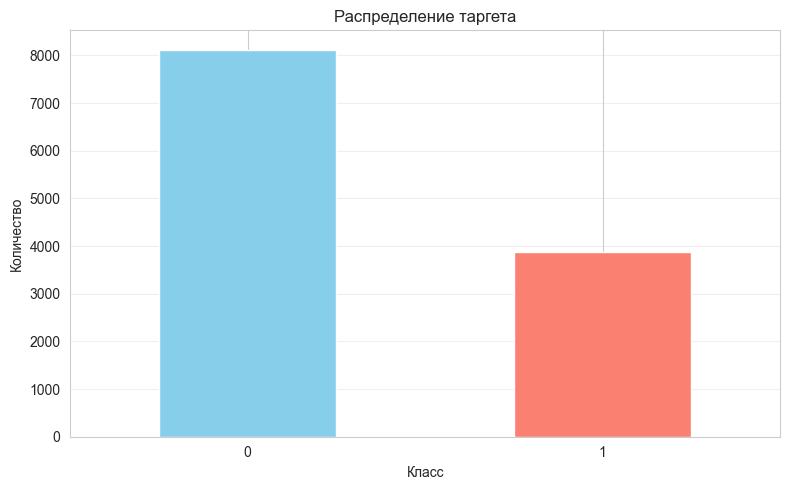

In [27]:
# Распределение таргета
target_dist = df['target'].value_counts(normalize=True)
print(f"Распределение таргета:\n{target_dist}")
print(f"\nКласс 0: {target_dist[0]:.2%}")
print(f"Класс 1: {target_dist[1]:.2%}")

plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение таргета')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# Подготовка признаков и таргета
# Исключаем 'id' и 'target' из признаков
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nСписок признаков ({len(X.columns)}):")
print(list(X.columns))


Размер X: (12000, 28)
Размер y: (12000,)

Список признаков (28):
['num01', 'num02', 'num03', 'num04', 'num05', 'num06', 'num07', 'num08', 'num09', 'num10', 'num11', 'num12', 'num13', 'num14', 'num15', 'num16', 'num17', 'num18', 'num19', 'num20', 'num21', 'num22', 'num23', 'num24', 'cat_contract', 'cat_region', 'cat_payment', 'tenure_months']


## 2.3.2. Train/Test-сплит и воспроизводимость


In [29]:
# Разделение на train/test
# Фиксируем random_state=42 для воспроизводимости
# Используем stratify=y для сохранения пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер train: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"Размер test: {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))


Размер train: 9600 (80.0%)
Размер test: 2400 (20.0%)

Распределение классов в train:
target
0    0.676562
1    0.323437
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


**Пояснение о фиксированном seed и стратификации:**

- `random_state=42` фиксирует случайность для воспроизводимости результатов
- `stratify=y` сохраняет пропорции классов в train и test, что важно при дисбалансе классов
- Это обеспечивает "честный" эксперимент: одинаковое разделение при каждом запуске


## 2.3.3. Baseline'ы


In [30]:
# Функция для вычисления метрик
def compute_metrics(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """Вычисляет метрики качества модели"""
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
    
    return metrics

# Словарь для хранения всех метрик
all_metrics = {}


In [31]:
# Baseline 1: DummyClassifier (most_frequent)
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_mf.fit(X_train, y_train)
y_pred_dummy = dummy_mf.predict(X_test)

metrics_dummy = compute_metrics(y_test, y_pred_dummy, model_name='DummyClassifier (most_frequent)')
all_metrics['dummy_mf'] = metrics_dummy

print("DummyClassifier (most_frequent):")
print(f"  Accuracy: {metrics_dummy['accuracy']:.4f}")
print(f"  F1: {metrics_dummy['f1']:.4f}")
print(f"\nИнтерпретация: модель всегда предсказывает самый частый класс (класс 0).")


DummyClassifier (most_frequent):
  Accuracy: 0.6767
  F1: 0.0000

Интерпретация: модель всегда предсказывает самый частый класс (класс 0).


In [32]:
# Baseline 2: LogisticRegression с StandardScaler
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

metrics_lr = compute_metrics(y_test, y_pred_lr, y_pred_proba_lr, model_name='LogisticRegression')
all_metrics['logistic_regression'] = metrics_lr

print("LogisticRegression:")
print(f"  Accuracy: {metrics_lr['accuracy']:.4f}")
print(f"  F1: {metrics_lr['f1']:.4f}")
print(f"  ROC-AUC: {metrics_lr['roc_auc']:.4f}")
print(f"\nИнтерпретация: линейная модель как базовый уровень для сравнения.")


LogisticRegression:
  Accuracy: 0.8275
  F1: 0.7076
  ROC-AUC: 0.8747

Интерпретация: линейная модель как базовый уровень для сравнения.


## 2.3.4. Модели недели 6


### DecisionTreeClassifier


In [33]:
# Подбор гиперпараметров для DecisionTree
# Используем GridSearchCV на train для подбора параметров
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

dt_base = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(
    dt_base, dt_param_grid, 
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {dt_grid.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучшие параметры: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 10}
Лучший CV-score (ROC-AUC): 0.9076


In [34]:
# Оценка на test
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_pred_proba_dt = dt_best.predict_proba(X_test)[:, 1]

metrics_dt = compute_metrics(y_test, y_pred_dt, y_pred_proba_dt, model_name='DecisionTreeClassifier')
all_metrics['decision_tree'] = metrics_dt

print("DecisionTreeClassifier (на test):")
print(f"  Accuracy: {metrics_dt['accuracy']:.4f}")
print(f"  F1: {metrics_dt['f1']:.4f}")
print(f"  ROC-AUC: {metrics_dt['roc_auc']:.4f}")


DecisionTreeClassifier (на test):
  Accuracy: 0.8767
  F1: 0.8000
  ROC-AUC: 0.9069


### RandomForestClassifier


In [35]:
# Подбор гиперпараметров для RandomForest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {rf_grid.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Лучший CV-score (ROC-AUC): 0.9685


In [36]:
# Оценка на test
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_pred_proba_rf = rf_best.predict_proba(X_test)[:, 1]

metrics_rf = compute_metrics(y_test, y_pred_rf, y_pred_proba_rf, model_name='RandomForestClassifier')
all_metrics['random_forest'] = metrics_rf

print("RandomForestClassifier (на test):")
print(f"  Accuracy: {metrics_rf['accuracy']:.4f}")
print(f"  F1: {metrics_rf['f1']:.4f}")
print(f"  ROC-AUC: {metrics_rf['roc_auc']:.4f}")


RandomForestClassifier (на test):
  Accuracy: 0.9246
  F1: 0.8775
  ROC-AUC: 0.9648


### GradientBoostingClassifier


In [37]:
# Подбор гиперпараметров для GradientBoosting
gb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_leaf': [1, 2, 5]
}

gb_base = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(
    gb_base, gb_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {gb_grid.best_score_:.4f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}
Лучший CV-score (ROC-AUC): 0.9729


In [38]:
# Оценка на test
gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test)
y_pred_proba_gb = gb_best.predict_proba(X_test)[:, 1]

metrics_gb = compute_metrics(y_test, y_pred_gb, y_pred_proba_gb, model_name='GradientBoostingClassifier')
all_metrics['gradient_boosting'] = metrics_gb

print("GradientBoostingClassifier (на test):")
print(f"  Accuracy: {metrics_gb['accuracy']:.4f}")
print(f"  F1: {metrics_gb['f1']:.4f}")
print(f"  ROC-AUC: {metrics_gb['roc_auc']:.4f}")


GradientBoostingClassifier (на test):
  Accuracy: 0.9296
  F1: 0.8873
  ROC-AUC: 0.9686


### StackingClassifier (опционально)


In [39]:
# Создание StackingClassifier с несколькими базовыми моделями
# Используем DecisionTree, RandomForest и LogisticRegression
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)),
    ('lr', Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42, max_iter=1000))]))
]

# Метамодель - LogisticRegression
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
y_pred_proba_stacking = stacking.predict_proba(X_test)[:, 1]

metrics_stacking = compute_metrics(y_test, y_pred_stacking, y_pred_proba_stacking, model_name='StackingClassifier')
all_metrics['stacking'] = metrics_stacking

print("StackingClassifier (на test):")
print(f"  Accuracy: {metrics_stacking['accuracy']:.4f}")
print(f"  F1: {metrics_stacking['f1']:.4f}")
print(f"  ROC-AUC: {metrics_stacking['roc_auc']:.4f}")


StackingClassifier (на test):
  Accuracy: 0.9192
  F1: 0.8701
  ROC-AUC: 0.9582


## 2.3.5. Метрики качества


In [40]:
# Сводная таблица метрик
metrics_df = pd.DataFrame(list(all_metrics.values()))
metrics_df = metrics_df.set_index('model')
print("Сводная таблица метрик на test:")
print(metrics_df.round(4))

# Сохранение метрик
metrics_df.to_json('artifacts/metrics_test.json', orient='index', indent=2)
metrics_df.to_csv('artifacts/metrics_test.csv')


Сводная таблица метрик на test:
                                 accuracy      f1  roc_auc
model                                                     
DummyClassifier (most_frequent)    0.6767  0.0000      NaN
LogisticRegression                 0.8275  0.7076   0.8747
DecisionTreeClassifier             0.8767  0.8000   0.9069
RandomForestClassifier             0.9246  0.8775   0.9648
GradientBoostingClassifier         0.9296  0.8873   0.9686
StackingClassifier                 0.9192  0.8701   0.9582


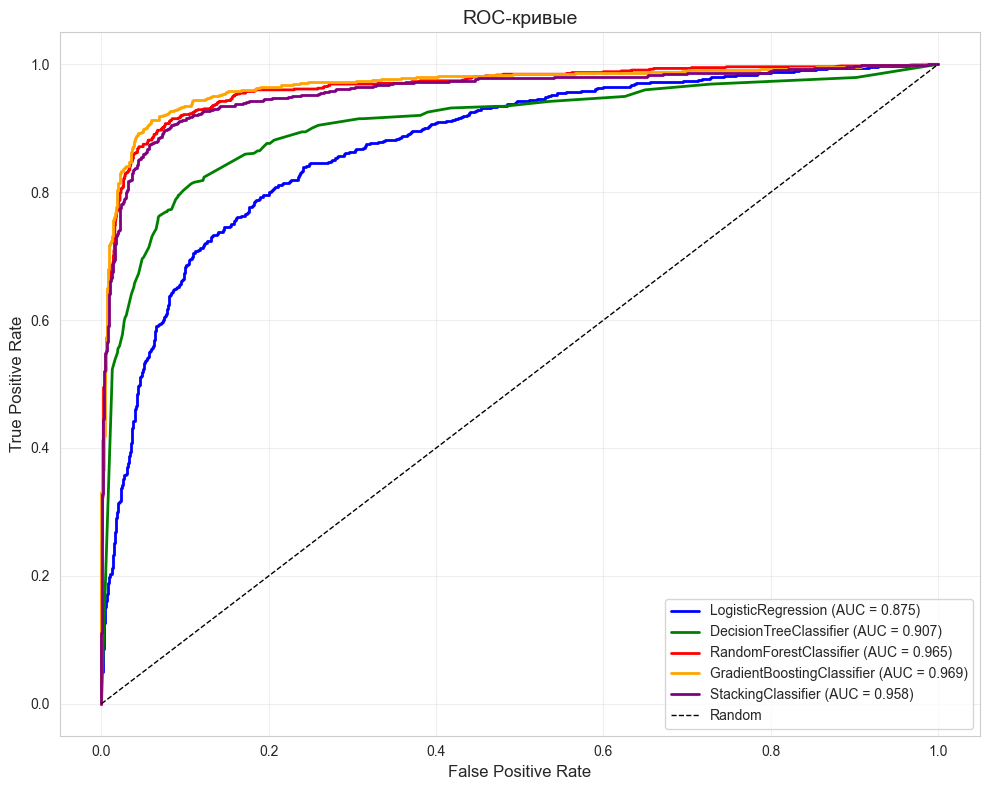

In [41]:
# ROC-кривые для всех моделей с вероятностями
models_with_proba = {
    'LogisticRegression': (y_pred_proba_lr, 'blue'),
    'DecisionTreeClassifier': (y_pred_proba_dt, 'green'),
    'RandomForestClassifier': (y_pred_proba_rf, 'red'),
    'GradientBoostingClassifier': (y_pred_proba_gb, 'orange'),
    'StackingClassifier': (y_pred_proba_stacking, 'purple')
}

plt.figure(figsize=(10, 8))
for name, (proba, color) in models_with_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Лучшая модель по ROC-AUC: GradientBoostingClassifier


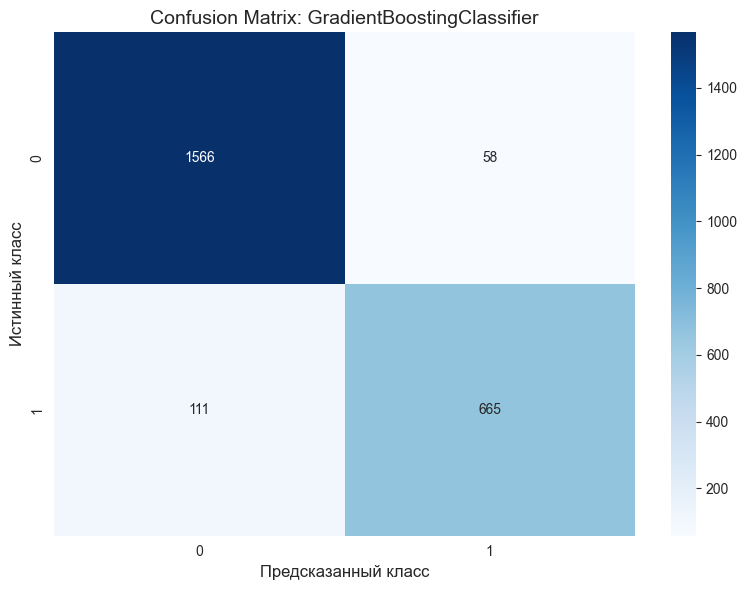

In [42]:
# Confusion Matrix для лучшей модели (по ROC-AUC)
best_model_name = metrics_df['roc_auc'].idxmax()
print(f"Лучшая модель по ROC-AUC: {best_model_name}")

# Находим предсказания лучшей модели
# Используем те же ключи, что и в metrics_df
best_predictions = {
    'LogisticRegression': y_pred_lr,
    'DecisionTreeClassifier': y_pred_dt,
    'RandomForestClassifier': y_pred_rf,
    'GradientBoostingClassifier': y_pred_gb,
    'StackingClassifier': y_pred_stacking
}

best_pred = best_predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.3.6. Интерпретация


In [43]:
# Permutation importance для лучшей модели
# Находим объект лучшей модели
# Используем те же ключи, что и в metrics_df
best_models = {
    'LogisticRegression': lr_pipeline,
    'DecisionTreeClassifier': dt_best,
    'RandomForestClassifier': rf_best,
    'GradientBoostingClassifier': gb_best,
    'StackingClassifier': stacking
}

best_model_obj = best_models[best_model_name]

# Вычисляем permutation importance
perm_importance = permutation_importance(
    best_model_obj, X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Создаём DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"Top-15 признаков по Permutation Importance ({best_model_name}):")
print(importance_df.head(15).to_string(index=False))


Top-15 признаков по Permutation Importance (GradientBoostingClassifier):
feature  importance_mean  importance_std
  num19         0.111833        0.005035
  num18         0.097875        0.005619
  num07         0.057292        0.002246
  num04         0.025458        0.003214
  num24         0.019375        0.003600
  num20         0.015667        0.003102
  num14         0.015583        0.002043
  num01         0.014250        0.002614
  num16         0.012542        0.002810
  num22         0.007042        0.001350
  num08         0.007042        0.002510
  num21         0.006042        0.001253
  num17         0.003917        0.001320
  num02         0.002208        0.001845
  num12         0.000958        0.000619


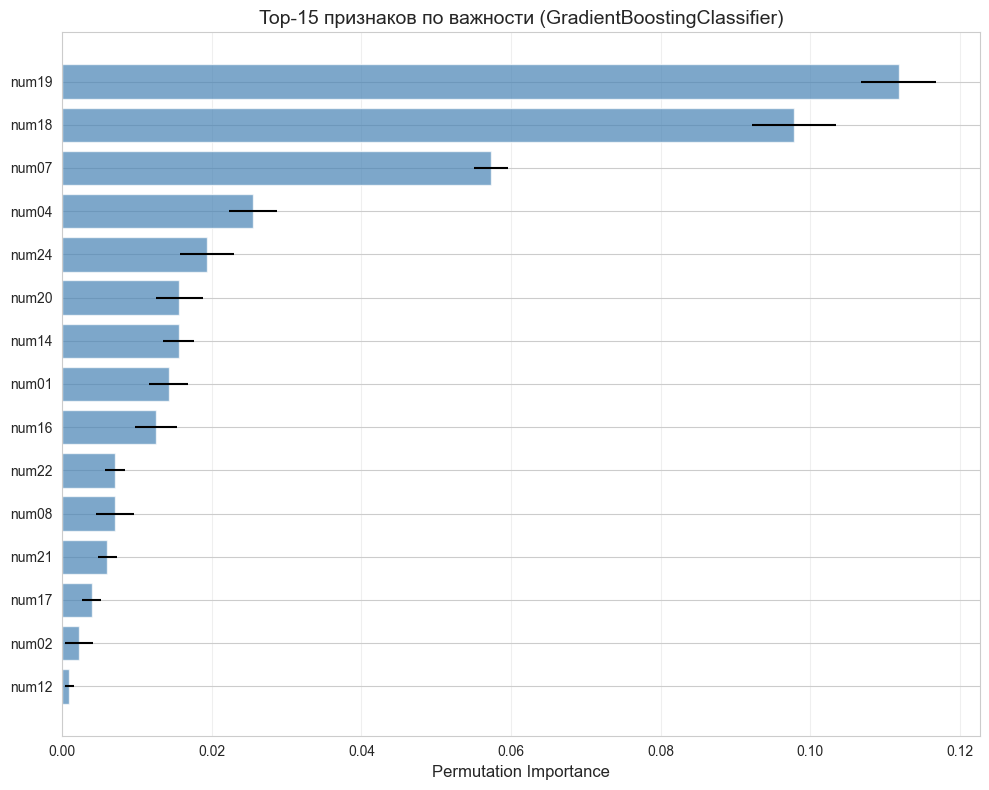

In [44]:
# Визуализация permutation importance (top-15)
top_15 = importance_df.head(15)

plt.figure(figsize=(10, 8))
y_pos = np.arange(len(top_15))
plt.barh(y_pos, top_15['importance_mean'], xerr=top_15['importance_std'], 
         color='steelblue', alpha=0.7)
plt.yticks(y_pos, top_15['feature'])
plt.xlabel('Permutation Importance', fontsize=12)
plt.title(f'Top-15 признаков по важности ({best_model_name})', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Интерпретация важности признаков:**

Выше представлены top-15 признаков, которые наиболее влияют на предсказание модели. Это помогает понять, какие характеристики данных наиболее важны для задачи классификации.


In [45]:
# Сохранение результатов поиска гиперпараметров
search_summaries = {
    'DecisionTreeClassifier': {
        'best_params': dt_grid.best_params_,
        'best_cv_score': float(dt_grid.best_score_),
        'test_score': float(metrics_dt['roc_auc'])
    },
    'RandomForestClassifier': {
        'best_params': {k: (int(v) if isinstance(v, (np.integer, np.int64)) else v) 
                       for k, v in rf_grid.best_params_.items()},
        'best_cv_score': float(rf_grid.best_score_),
        'test_score': float(metrics_rf['roc_auc'])
    },
    'GradientBoostingClassifier': {
        'best_params': {k: (int(v) if isinstance(v, (np.integer, np.int64)) else v) 
                       for k, v in gb_grid.best_params_.items()},
        'best_cv_score': float(gb_grid.best_score_),
        'test_score': float(metrics_gb['roc_auc'])
    }
}

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print("Результаты поиска гиперпараметров сохранены в artifacts/search_summaries.json")


Результаты поиска гиперпараметров сохранены в artifacts/search_summaries.json


In [46]:
# Сохранение лучшей модели
joblib.dump(best_model_obj, 'artifacts/best_model.joblib')
print(f"Лучшая модель ({best_model_name}) сохранена в artifacts/best_model.joblib")

# Сохранение метаданных лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'best_params': str(best_model_obj.get_params()) if hasattr(best_model_obj, 'get_params') else None,
    'test_metrics': {
        'accuracy': float(metrics_df.loc[best_model_name, 'accuracy']),
        'f1': float(metrics_df.loc[best_model_name, 'f1']),
        'roc_auc': float(metrics_df.loc[best_model_name, 'roc_auc'])
    }
}

with open('artifacts/best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print(f"\nМетаданные сохранены в artifacts/best_model_meta.json")
print(f"\nЛучшая модель: {best_model_name}")
print(f"  Accuracy: {best_model_meta['test_metrics']['accuracy']:.4f}")
print(f"  F1: {best_model_meta['test_metrics']['f1']:.4f}")
print(f"  ROC-AUC: {best_model_meta['test_metrics']['roc_auc']:.4f}")


Лучшая модель (GradientBoostingClassifier) сохранена в artifacts/best_model.joblib

Метаданные сохранены в artifacts/best_model_meta.json

Лучшая модель: GradientBoostingClassifier
  Accuracy: 0.9296
  F1: 0.8873
  ROC-AUC: 0.9686
